# ENMV - Statistical analysis 


This notebook:
- loads the dataset (`Data_RESISTE_ENMV.xlsx`),
- reproduces aggregated tables/heatmaps,
- visualizes lineage heterogeneity,
- quantifies overdispersion vs a Binomial model,
- proposes data‑driven estimates for the Beta–Binomial concentration parameter $\kappa$.

Outputs:
- PNG figures (heatmaps, lineage plots, overdispersion diagnostics)

In [1]:
# --- Imports ---
import os, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats, optimize

# --- Paths ---
DATA_RESISTE = "Data_RESISTE_ENMV.xlsx"   # lineage-level

# --- Hosts ---
HOSTS = ["CH", "LA", "SA", "SO", "ZI"]
H = len(HOSTS)
host_to_idx = {h:i for i,h in enumerate(HOSTS)}

host_map = {
    "chicorée": "CH",
    "laitue": "LA",
    "salsifis": "SA",
    "souci": "SO",
    "zinnia": "ZI",
}

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

## 1) Load lineage‑level dataset and basic checks

In [2]:
assert os.path.exists(DATA_RESISTE), f"Missing {DATA_RESISTE}. Put it next to this notebook."
raw = pd.read_excel(DATA_RESISTE, sheet_name="ENMV")

import warnings
warnings.filterwarnings("ignore", message="Workbook contains no default style")

needed = ["sp_inoc", "soucheV", "plante_source", "infected"]
missing = [c for c in needed if c not in raw.columns]
assert not missing, f"Missing columns: {missing}. Columns found: {list(raw.columns)}"

raw["target"]  = raw["sp_inoc"].map(host_map)
raw["source"]  = raw["soucheV"].astype(str)
raw["lineage"] = raw["plante_source"].astype(str)
raw["y"]       = raw["infected"].astype(int)

valid_sources = ["7098MP1"] + HOSTS
raw = raw[raw["source"].isin(valid_sources)].copy()
raw = raw[raw["target"].isin(HOSTS)].copy()

print("Rows:", len(raw))
display(raw[["source","target","lineage","y"]].head())

clonal = raw[raw["source"]=="7098MP1"].copy()
evolved = raw[raw["source"]!="7098MP1"].copy()

print("\nClonal targets counts (protocol-dependent):")
clonal_counts = clonal.groupby("target")["y"].agg(["sum","count"]).reindex(HOSTS)
clonal_counts["rate"] = clonal_counts["sum"] / clonal_counts["count"]
display(clonal_counts)

print("\nEvolved design check: n plants per (source, lineage, target) should be 12:")
check = evolved.groupby(["source","lineage","target"])["y"].count().reset_index(name="n")
display(check["n"].value_counts().sort_index())
assert check["n"].min()==12 and check["n"].max()==12, "Expected 12 plants per (source,lineage,target)."

lineages_by_source = {s: sorted(check[check["source"]==s]["lineage"].unique()) for s in HOSTS}
print("\n# lineages per source:", {s: len(v) for s,v in lineages_by_source.items()})

/home/lroques/.local/lib/python3.9/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Rows: 2560


,source,target,lineage,y
0,LA,SO,LA206601,0
1,LA,SO,LA206601,0
2,LA,SO,LA206601,0
3,LA,SA,LA206601,1
4,LA,SA,LA206601,1



Clonal targets counts (protocol-dependent):


,sum,count,rate
target,,,
CH,19,20,0.950
LA,16,20,0.800
SA,21,40,0.525
SO,0,60,0.000
ZI,4,20,0.200



Evolved design check: n plants per (source, lineage, target) should be 12:


n
12    200
Name: count, dtype: int64


# lineages per source: {'CH': 8, 'LA': 8, 'SA': 8, 'SO': 8, 'ZI': 8}


## 2) Aggregated tables (clonal + evolved)

In [3]:
display(clonal_counts)

# Evolved aggregated: sum over 8 lineages x 12 plants = 96 per (source,target)
evolved_counts = evolved.groupby(["source","target"])["y"].agg(["sum","count"]).reset_index()
evolved_counts["rate"] = evolved_counts["sum"] / evolved_counts["count"]

mat_rate = evolved_counts.pivot(index="source", columns="target", values="rate").reindex(index=HOSTS, columns=HOSTS)
mat_sum  = evolved_counts.pivot(index="source", columns="target", values="sum").reindex(index=HOSTS, columns=HOSTS)

print("Aggregated success rates (evolved):")
display(mat_rate)

# x/N table
pretty = mat_sum.copy().astype(int).astype(str) + "/96"
pretty.index.name = "Source"
pretty.columns.name = "Target"
print("Aggregated counts as x/96 (evolved):")
display(pretty)

,sum,count,rate
target,,,
CH,19,20,0.950
LA,16,20,0.800
SA,21,40,0.525
SO,0,60,0.000
ZI,4,20,0.200


Aggregated success rates (evolved):


target,CH,LA,SA,SO,ZI
source,,,,,
CH,0.989583,0.770833,0.583333,0.000000,0.156250
LA,0.989583,0.718750,0.552083,0.052083,0.166667
SA,1.000000,0.697917,0.531250,0.020833,0.145833
SO,0.781250,0.802083,0.614583,1.000000,0.802083
ZI,0.937500,0.885417,0.468750,0.854167,0.927083


Aggregated counts as x/96 (evolved):


Target,CH,LA,SA,SO,ZI
Source,,,,,
CH,95/96,74/96,56/96,0/96,15/96
LA,95/96,69/96,53/96,5/96,16/96
SA,96/96,67/96,51/96,2/96,14/96
SO,75/96,77/96,59/96,96/96,77/96
ZI,90/96,85/96,45/96,82/96,89/96


### Heatmaps / barplots

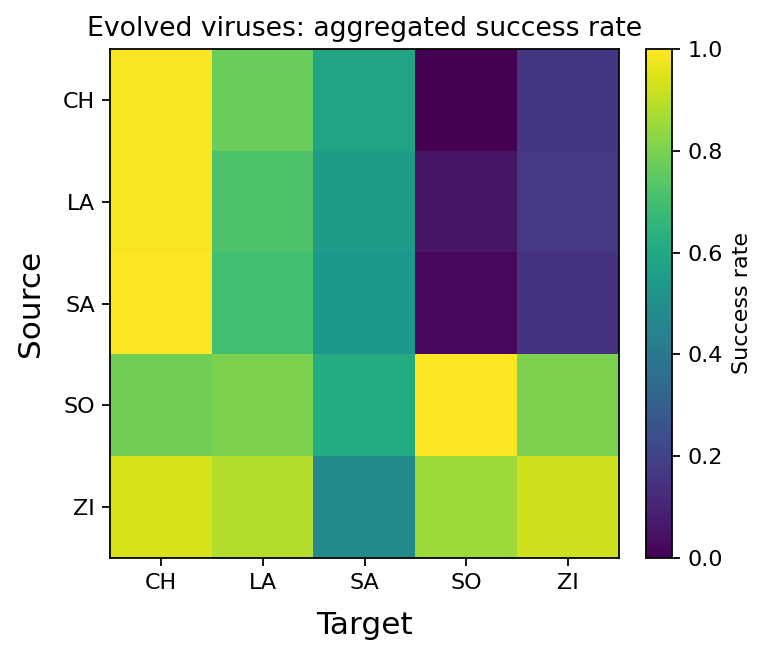

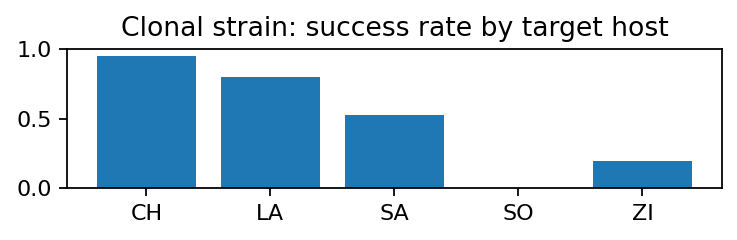

In [4]:
plt.figure(figsize=(5.2,4.2), dpi=160)
im = plt.imshow(mat_rate.values, vmin=0, vmax=1, origin="upper")
plt.xticks(range(H), HOSTS)
plt.yticks(range(H), HOSTS)
plt.xlabel("Target", fontsize=14, labelpad=8)
plt.ylabel("Source", fontsize=14, labelpad=8)


plt.title("Evolved viruses: aggregated success rate")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Success rate")
plt.tight_layout()
plt.savefig("fig_heatmap_agg.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(4.8,1.6), dpi=160)
plt.bar(HOSTS, clonal_counts["rate"].values)
plt.ylim(0,1)
plt.title("Clonal strain: success rate by target host")
plt.tight_layout()
plt.savefig("fig_clonal_rates.png", bbox_inches="tight")
plt.show()

## 3) Lineage‑level variation

Each evolved (source $j$, target $k$) cell has **8 lineages**, each tested on **12 plants**.
Below we visualize the distribution of lineage success rates $y^{(\ell)}/12$ within each cell.

,source,lineage,target,succ,n,rate
0,CH,CH206101,CH,12,12,1.000000
1,CH,CH206101,LA,12,12,1.000000
2,CH,CH206101,SA,8,12,0.666667
3,CH,CH206101,SO,0,12,0.000000
4,CH,CH206101,ZI,2,12,0.166667


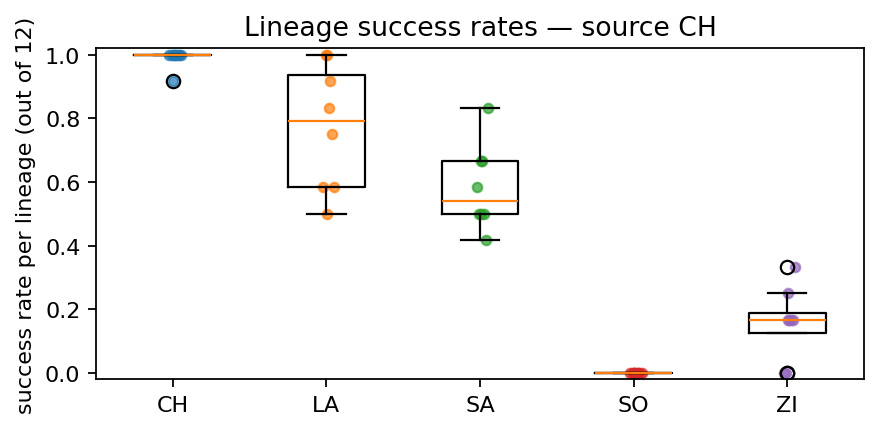

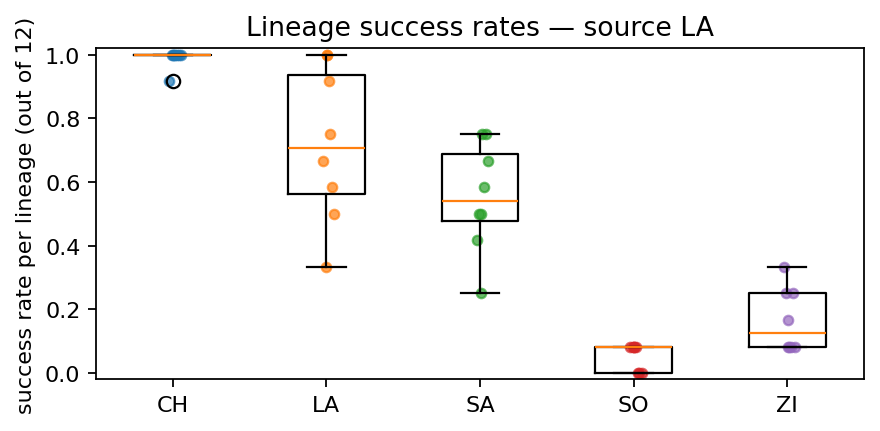

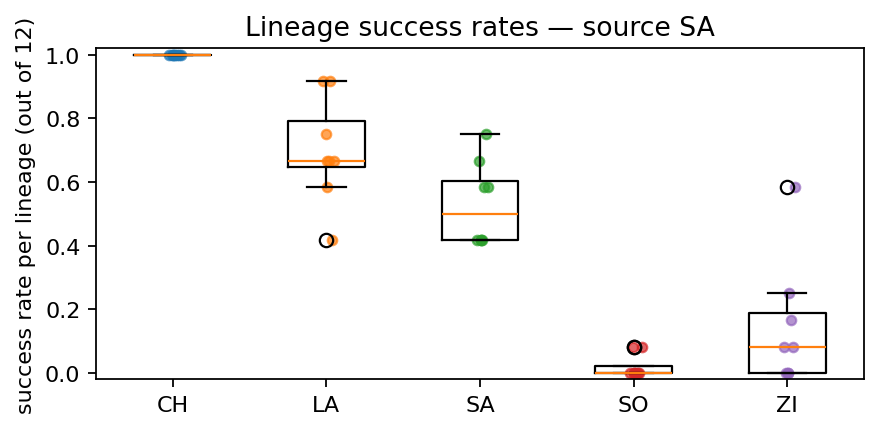

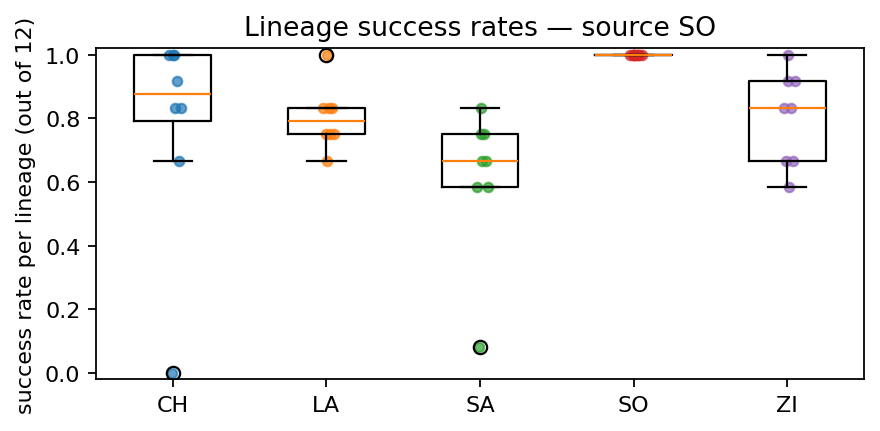

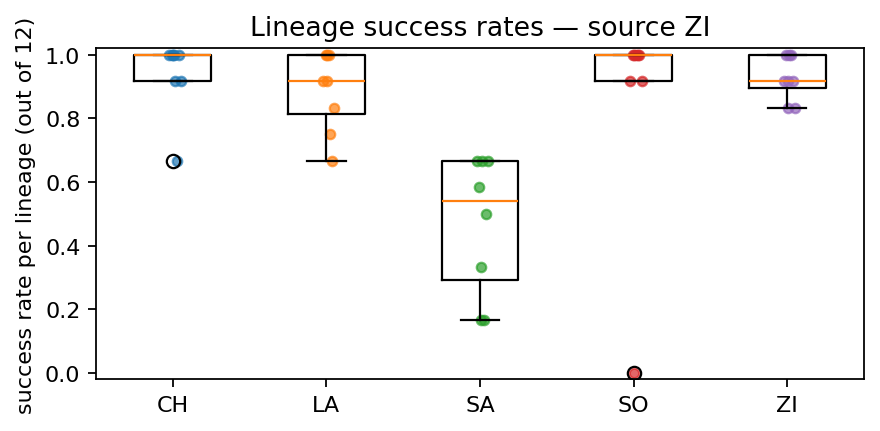

In [5]:
lin_counts = evolved.groupby(["source","lineage","target"])["y"].agg(["sum","count"]).reset_index()
lin_counts.rename(columns={"sum":"succ","count":"n"}, inplace=True)
lin_counts["rate"] = lin_counts["succ"] / lin_counts["n"]
display(lin_counts.head())

# Boxplots across targets, one panel per source
for src in HOSTS:
    sub = lin_counts[lin_counts["source"]==src].copy()
    data = [sub[sub["target"]==t]["rate"].values for t in HOSTS]

    plt.figure(figsize=(5.6,2.8), dpi=160)
    try:
        plt.boxplot(data, labels=HOSTS, showfliers=True)
    except TypeError:
    # fallback
        plt.boxplot(data, showfliers=True)
        plt.xticks(range(1, len(HOSTS)+1), HOSTS)
    for i, t in enumerate(HOSTS, start=1):
        y = sub[sub["target"]==t]["rate"].values
        x = np.random.default_rng(0).normal(loc=i, scale=0.04, size=len(y))
        plt.scatter(x, y, s=18, alpha=0.7)
    plt.ylim(-0.02, 1.02)
    plt.title(f"Lineage success rates — source {src}")
    plt.ylabel("success rate per lineage (out of 12)")
    plt.tight_layout()
    plt.savefig(f"fig_boxplots_source_{src}.png", bbox_inches="tight")
    plt.show()

## 4) Overdispersion vs Binomial within each $(j,k)$

Null model for a given $(j,k)$:
- lineage counts $Y_{jk}^{(\ell)}\sim\mathrm{Binomial}(n=12, p_{jk})$ i.i.d. across $\ell=1..8$.

We test this using a Pearson $\chi^2$ statistic:
$$
X^2_{jk}=\sum_{\ell=1}^8 \frac{\left(Y_{jk}^{(\ell)}-12\hat p_{jk}\right)^2}{12\hat p_{jk}(1-\hat p_{jk})},
\quad \hat p_{jk}=\frac{\sum_\ell Y_{jk}^{(\ell)}}{96}.
$$
Under the null, $X^2_{jk}\approx\chi^2_{7}$ (heuristic; works best when $\hat p_{jk}$ not too close to 0/1).

We also compute a **dispersion factor** $\phi_{jk}=X^2_{jk}/7$.

,p_hat,chi2,df,p_value,phi,informative,source,target,p_value_adj_bh
0,0.989583,NaN,7,NaN,NaN,False,CH,CH,NaN
1,0.770833,18.633907,7,9.414905e-03,2.661987,True,CH,LA,2.689973e-02
2,0.583333,6.171429,7,5.198814e-01,0.881633,True,CH,SA,6.020976e-01
3,0.000000,NaN,7,NaN,NaN,False,CH,SO,NaN
4,0.156250,8.138272,7,3.205594e-01,1.162610,True,CH,ZI,4.931683e-01
5,0.989583,NaN,7,NaN,NaN,False,LA,CH,NaN
6,0.718750,24.682770,7,8.635560e-04,3.526110,True,LA,LA,4.317780e-03
7,0.552083,10.067573,7,1.847764e-01,1.438225,True,LA,SA,3.079606e-01
8,0.052083,3.164835,7,8.693464e-01,0.452119,True,LA,SO,8.693464e-01
9,0.166667,6.000000,7,5.397494e-01,0.857143,True,LA,ZI,6.020976e-01



Global dispersion factor phi (informative cells): 2.522229052936382


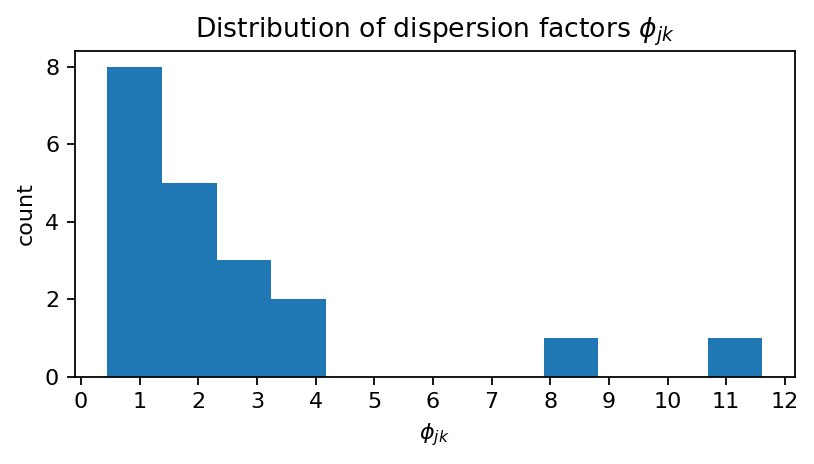

In [6]:
def overdispersion_test_cell(sub_rates: pd.DataFrame):
    y = sub_rates["succ"].values.astype(float)
    n = float(sub_rates["n"].iloc[0])
    p_hat = y.sum() / (len(y)*n)
    # Extreme p -> Pearson chi2 unstable
    if p_hat < 0.02 or p_hat > 0.98:
        return dict(p_hat=p_hat, chi2=np.nan, df=7, p_value=np.nan, phi=np.nan, informative=False)
    denom = n*p_hat*(1-p_hat)
    chi2 = float(np.sum((y - n*p_hat)**2 / denom))
    df = len(y) - 1
    pval = float(1 - stats.chi2.cdf(chi2, df))
    phi = chi2 / df
    return dict(p_hat=p_hat, chi2=chi2, df=df, p_value=pval, phi=phi, informative=True)

rows = []
for src in HOSTS:
    for tgt in HOSTS:
        sub = lin_counts[(lin_counts["source"]==src) & (lin_counts["target"]==tgt)].copy()
        d = overdispersion_test_cell(sub)
        d.update(source=src, target=tgt)
        rows.append(d)

od = pd.DataFrame(rows)

import matplotlib.ticker as mticker

# BH adjustment on informative p-values
od["p_value_adj_bh"] = np.nan
mask = od["informative"] & od["p_value"].notna()
p = od.loc[mask, "p_value"].values
if len(p):
    order = np.argsort(p)
    ranked = p[order]
    m = len(ranked)
    q = ranked * m / (np.arange(m)+1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    adj = np.empty_like(q)
    adj[order] = np.clip(q, 0, 1)
    od.loc[mask, "p_value_adj_bh"] = adj

display(od.sort_values(["source","target"]))

phi_global = od.loc[mask, "chi2"].sum() / od.loc[mask, "df"].sum()
print("\nGlobal dispersion factor phi (informative cells):", float(phi_global))

plt.figure(figsize=(5.2,3.0), dpi=160)
vals = od.loc[mask, "phi"].values
plt.hist(vals, bins=12)
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
#plt.axvline(1.0, linestyle="--", color="k")
plt.title("Distribution of dispersion factors $\phi_{jk}$")
plt.xlabel("$\phi_{jk}$")
plt.ylabel("count")
plt.tight_layout()
plt.savefig("fig_phi_hist.png", bbox_inches="tight")
plt.show()

## 5) Estimating $\kappa$ for a Beta–Binomial

We use the Beta–Binomial parameterization:
$$
p^{(\ell)}_{jk}\sim\mathrm{Beta}(\kappa p_{jk},\kappa(1-p_{jk})),\qquad
Y^{(\ell)}_{jk}\mid p^{(\ell)}_{jk}\sim \mathrm{Binomial}(12,p^{(\ell)}_{jk}).
$$
Then:
$$
\mathbb E[Y]=12p,\qquad
\mathrm{Var}(Y)=12p(1-p)\,\frac{12+\kappa}{1+\kappa}.
$$

Two data-driven approaches:
1) **Method-of-moments per cell** (gives $\kappa_{jk}$, noisy but diagnostic)
2) **Global pooled pseudo-likelihood** for a single $\kappa$ over all cells (using plug-in $\hat p_{jk}$)

,p_hat,kappa,rho,informative,source,target,y_sum,log10_kappa
0,0.989583,1044.000000,0.000957,True,CH,CH,95,3.018700
1,0.770833,5.618585,0.151090,True,CH,LA,74,0.749627
2,0.583333,inf,0.000000,False,CH,SA,56,NaN
3,0.000000,inf,0.000000,False,CH,SO,0,NaN
4,0.156250,66.646421,0.014783,True,CH,ZI,15,1.823777
5,0.989583,1044.000000,0.000957,True,LA,CH,95,3.018700
6,0.718750,3.354521,0.229646,True,LA,LA,69,0.525631
7,0.552083,24.101273,0.039839,True,LA,SA,53,1.382040
8,0.052083,inf,0.000000,False,LA,SO,5,NaN
9,0.166667,inf,0.000000,False,LA,ZI,16,NaN


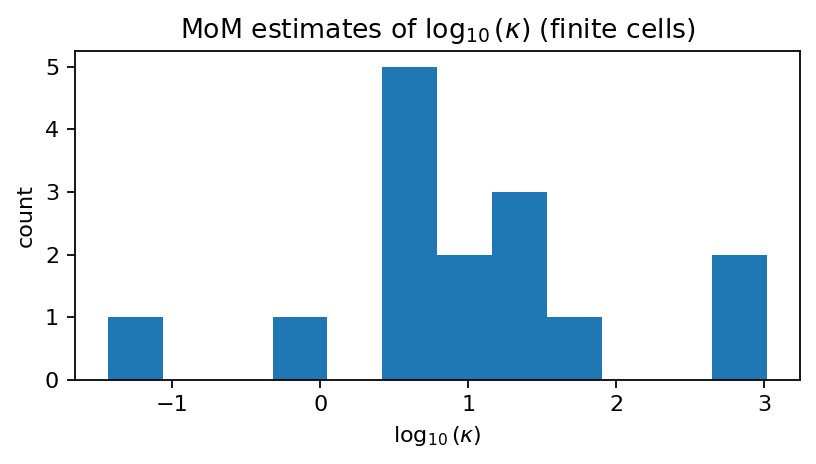

Median finite kappa: 7.535719460947689
Geometric-mean finite kappa: 10.308965499551773


In [7]:
def kappa_mom_cell(y: np.ndarray, n: int):
    mean_y = y.mean()
    var_y  = y.var(ddof=1)
    p_hat = mean_y / n
    if p_hat < 1e-6 or p_hat > 1-1e-6:
        return dict(p_hat=float(p_hat), kappa=np.inf, rho=0.0, informative=False)

    var_bin = n * p_hat * (1-p_hat)
    if var_y <= var_bin * (1 + 1e-6):
        return dict(p_hat=float(p_hat), kappa=np.inf, rho=0.0, informative=False)

    V = var_y / var_bin
    rho = (V - 1.0) / (n - 1.0)  # rho = 1/(1+kappa)
    rho = float(np.clip(rho, 1e-6, 0.999))
    kappa = 1.0/rho - 1.0
    return dict(p_hat=float(p_hat), kappa=float(kappa), rho=float(rho), informative=True)

kappa_rows = []
for src in HOSTS:
    for tgt in HOSTS:
        sub = lin_counts[(lin_counts["source"]==src) & (lin_counts["target"]==tgt)]
        y = sub["succ"].values.astype(int)
        out = kappa_mom_cell(y, n=12)
        out.update(source=src, target=tgt, y_sum=int(y.sum()))
        kappa_rows.append(out)

kap = pd.DataFrame(kappa_rows)
kap["log10_kappa"] = np.where(np.isfinite(kap["kappa"]), np.log10(kap["kappa"]), np.nan)
display(kap.sort_values(["source","target"]))

finite = kap[np.isfinite(kap["kappa"]) & (kap["kappa"]>0)]
plt.figure(figsize=(5.2,3.0), dpi=160)
plt.hist(finite["log10_kappa"].values, bins=12)
plt.title("MoM estimates of $\log_{10}(\kappa)$ (finite cells)")
plt.xlabel("$\log_{10}(\kappa)$")
plt.ylabel("count")
plt.tight_layout()
plt.savefig("fig_kappa_mom_hist.png", bbox_inches="tight")
plt.show()

if len(finite):
    med = float(np.median(finite["kappa"].values))
    gm  = float(10**np.mean(np.log10(finite["kappa"].values)))
    print("Median finite kappa:", med)
    print("Geometric-mean finite kappa:", gm)
else:
    print("No finite kappa estimates from moments (likely too many extreme p).")

Pooled pseudo-LL estimate:
  log10(kappa) = 0.9777173770427655
  kappa        = 9.499863760844358


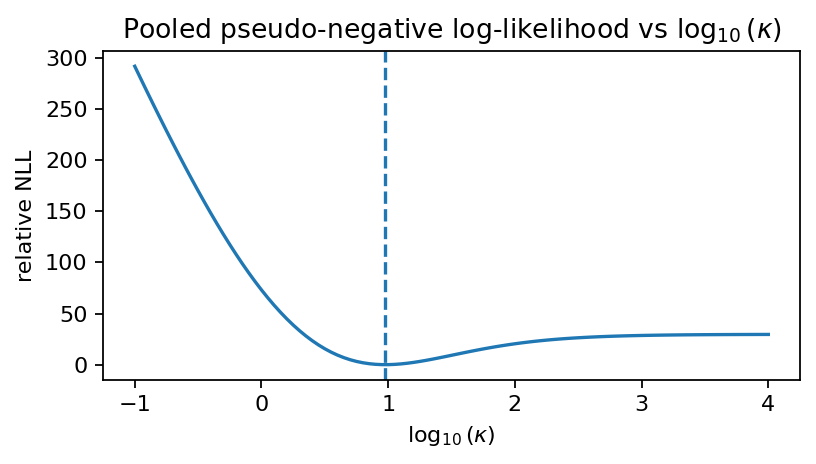


Suggested value for kappa = 9.499863760844358


In [8]:
def pooled_kappa_pseudoll(log10_kappa, data_cells):
    kappa = 10**log10_kappa
    if kappa <= 0:
        return np.inf
    ll = 0.0
    for y, n, p_hat in data_cells:
        p_hat = float(np.clip(p_hat, 1e-6, 1-1e-6))
        a = kappa * p_hat
        b = kappa * (1-p_hat)
        ll += float(np.sum(stats.betabinom.logpmf(y, n, a, b)))
    return -ll

data_cells = []
for src in HOSTS:
    for tgt in HOSTS:
        sub = lin_counts[(lin_counts["source"]==src) & (lin_counts["target"]==tgt)]
        y = sub["succ"].values.astype(int)
        n = int(sub["n"].iloc[0])
        p_hat = y.sum() / (len(y)*n)
        data_cells.append((y, n, p_hat))

grid = np.linspace(-1, 4, 101)  # kappa 0.1..1e4
vals = np.array([pooled_kappa_pseudoll(g, data_cells) for g in grid])
g0 = float(grid[np.argmin(vals)])

res = optimize.minimize_scalar(lambda g: pooled_kappa_pseudoll(g, data_cells),
                               bounds=(max(-1, g0-0.8), min(4, g0+0.8)),
                               method="bounded")
log10_kappa_hat = float(res.x)
kappa_hat = float(10**log10_kappa_hat)

print("Pooled pseudo-LL estimate:")
print("  log10(kappa) =", log10_kappa_hat)
print("  kappa        =", kappa_hat)

plt.figure(figsize=(5.2,3.0), dpi=160)
plt.plot(grid, vals - vals.min(), lw=1.5)
plt.axvline(log10_kappa_hat, linestyle="--")
plt.title("Pooled pseudo-negative log-likelihood vs $\log_{10}(\kappa)$")
plt.xlabel("$\log_{10}(\kappa)$")
plt.ylabel("relative NLL")
plt.tight_layout()
plt.savefig("fig_kappa_pseudoll.png", bbox_inches="tight")
plt.show()


print("\nSuggested value for kappa =", float(kappa_hat))